# 03-V2 — LightGBM Deep Momentum Network

22 features → LightGBM (L2) → `sigmoid(alpha* × score)` → EMA (halflife=10j) → filtre CPD → `positions_v2.parquet` → NB04.

Walk-forward : 16 folds annuels 2011–2026, fenêtres expansives depuis 2006.

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import yaml
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

ROOT = Path.cwd()
if not (ROOT / 'configs' / 'default.yaml').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# pipeline functions (feature building, walk-forward, training, position post-processing) from src/nb03_dmn_v2.py
from src.nb03_dmn_v2 import (
    resolve_project_root,
    load_nb03_inputs, build_feature_matrix,
    input_summary,
    FEATURE_COLS, TARGET_COL,
    run_walk_forward, walk_forward_splits,
    train_fold_lgb, compute_shap,
    smooth_positions, apply_cpd_filter,
    save_nb03_outputs,
)

ROOT = resolve_project_root(ROOT)
cfg  = yaml.safe_load(open(ROOT / 'configs' / 'default.yaml'))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\justi\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\justi\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\justi\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\justi\anaconda3\Lib\site-pack


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\justi\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\justi\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\justi\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\justi\anaconda3\Lib\site-pack

In [2]:
lcfg = cfg['lgbm']

LGB_N_ESTIMATORS  = lcfg['n_estimators']
POSITION_HALFLIFE = lcfg['position_halflife']
ALPHA_MAX         = lcfg['alpha_max']
WINDOW_YEARS      = lcfg['window_years']   # None = expanding

LGB_PARAMS = {
    'learning_rate':     lcfg['learning_rate'],
    'max_depth':         lcfg['max_depth'],
    'num_leaves':        lcfg['num_leaves'],
    'min_child_samples': lcfg['min_child_samples'],
    'subsample':         lcfg['subsample'],
    'subsample_freq':    1,
    'colsample_bytree':  lcfg['colsample_bytree'],
    'reg_alpha':         lcfg['reg_alpha'],
    'reg_lambda':        lcfg['reg_lambda'],
    'random_state':      cfg['dmn']['seed'],
    'n_jobs':            -1,
    'verbose':           -1,
}

print(f"LightGBM : {LGB_N_ESTIMATORS} trees | max_depth={LGB_PARAMS['max_depth']} "
      f"| num_leaves={LGB_PARAMS['num_leaves']}")
print(f"Position : EMA halflife={POSITION_HALFLIFE}d | alpha in [1, {ALPHA_MAX}]")
print(f"Protocol : {'expanding' if WINDOW_YEARS is None else str(WINDOW_YEARS) + 'y rolling'} window")


LightGBM : 300 trees | max_depth=4 | num_leaves=15
Position : EMA halflife=10d | alpha in [1, 200]
Protocol : expanding window


## 1. Données

Panel NB01 (rendements + momentum) fusionné avec scores CPD NB02. Cible : `next_return` (J+1).

| Méthode CPD | AUC | Recall | |
|---|---|---|---|
| CUSUM mean+variance | 0.605 | 78.7% | ✅ retenu |
| BOCPD (Adams-MacKay 2007) | 0.531 | 50.0% | ✅ retenu — corrélation CUSUM=0.11, signal complémentaire |
| Binary Segmentation / GP Matérn | — | — | ❌ exclus |

In [3]:
data         = load_nb03_inputs(ROOT)
panel        = data["panel"]
cpd_features = data["cpd_features"]

feat         = build_feature_matrix(panel, cpd_features)
feature_cols = [c for c in FEATURE_COLS if c in feat.columns]

display(input_summary(feat))

,item,value
0,rows,"2,659,579"
1,tickers,"1,299"
2,date range,2006-03-14 -> 2026-05-05
3,features,22
4,model,LightGBM L2 + calibration alpha* Sharpe-net (V2)
5,target,next_return


## 2. Features — 22 signaux

| Groupe | Nb | |
|---|---|---|
| Momentum | 18 | `norm_ret` ×5, `macd` ×3 paires, `ewma_vol` — courant + lag-1 |
| Région | 2 | `region_rel_1d` — sur/sous-perf vs Europe — courant + lag-1 |
| CPD stock | 2 | `nu_cusum_lag1` + `nu_bocpd_lag1` — deux méthodes complémentaires (corrélation=0.11) |

> 📌 *Les lag-1 donnent à LightGBM la dynamique temporelle sans avoir besoin de séquences (pas de LSTM).*

## 3. Architecture

LightGBM L2/MSE, 300 arbres, profondeur 4, L1+L2 — adapté au signal faible (IC ≈ 0.005).

**alpha\*** : calibré sur Sharpe net 25bps. Alpha≈1 → positions plates | Alpha≈200 → signal amplifié.

> ⚠️ *Sur plusieurs folds : alpha\* = 1 → modèle ≈ equal-weight. L'ajout BOCPD améliore marginalement le signal (gain limité par l'IC, pas par l'architecture).*

In [4]:
display(pd.DataFrame([
    {"paramètre": "n_estimators",       "valeur": str(LGB_N_ESTIMATORS),               "rôle": "Nombre d'arbres — 300 = compromis biais/variance"},
    {"paramètre": "learning_rate",      "valeur": str(LGB_PARAMS["learning_rate"]),     "rôle": "Shrinkage — correction lente, convergence stable"},
    {"paramètre": "max_depth",          "valeur": str(LGB_PARAMS["max_depth"]),         "rôle": "Profondeur max — 4 = arbres simples, peu de mémorisation"},
    {"paramètre": "min_child_samples",  "valeur": str(LGB_PARAMS["min_child_samples"]), "rôle": "Min observations/feuille — évite les splits sur outliers"},
    {"paramètre": "reg_alpha (L1)",     "valeur": str(LGB_PARAMS["reg_alpha"]),         "rôle": "Pénalité L1 — pousse les poids inutiles vers 0"},
    {"paramètre": "reg_lambda (L2)",    "valeur": str(LGB_PARAMS["reg_lambda"]),        "rôle": "Pénalité L2 — réduit les grands coefficients"},
    {"paramètre": "EMA halflife",       "valeur": str(POSITION_HALFLIFE) + " jours",   "rôle": "Lissage temporel des positions — turnover ÷ ~10"},
]))

,paramètre,valeur,rôle
0,n_estimators,300,Nombre d'arbres — 300 = compromis biais/variance
1,learning_rate,0.05,"Shrinkage — correction lente, convergence stable"
2,max_depth,4,"Profondeur max — 4 = arbres simples, peu de mé..."
3,min_child_samples,20,Min observations/feuille — évite les splits su...
4,reg_alpha (L1),0.1,Pénalité L1 — pousse les poids inutiles vers 0
5,reg_lambda (L2),0.1,Pénalité L2 — réduit les grands coefficients
6,EMA halflife,10 jours,Lissage temporel des positions — turnover ÷ ~10


## 4. Walk-forward — 2011–2026

16 folds annuels, fenêtres expansives depuis 2006. Les 10% finaux de chaque fold calibrent alpha*.

> ⚠️ *Fold 2023 : IC = −0.0041 (négatif) + alpha\* = 200 → signal inverse sur cet horizon.*

In [5]:
# 16 annual expanding-window folds: each fold trains on all years up to test_year-1
splits = walk_forward_splits(feat, window_years=WINDOW_YEARS)

fold_rows = []
for i, sp in enumerate(splits, start=1):
    train_start = sp["train_start"].year if sp.get("train_start") else 2006
    train_end = sp["train_end"].year
    fold_rows.append({
        "fold": i,
        "train": f"{train_start} -> {train_end}",
        "test": sp["test_year"],
        "n_train_rows": feat.loc[feat["date"] <= sp["train_end"]].shape[0],
    })

display(pd.DataFrame(fold_rows))

# trains one LightGBM model per fold, calibrates alpha* on validation, predicts on the test year
positions, fold_metrics = run_walk_forward(
    feat,
    feature_cols=feature_cols,
    verbose=False,
    window_years=WINDOW_YEARS,
)

fold_display = fold_metrics[["test_year", "val_ic", "alpha_calibrated", "val_sharpe"]].copy()
fold_display = fold_display.rename(columns={
    "test_year": "Annee test",
    "val_ic": "IC (val)",
    "alpha_calibrated": "alpha* calibre",
    "val_sharpe": "Sharpe brut (val)",
})
fold_display["alpha* calibre"] = fold_display["alpha* calibre"].astype(int)
fold_display["IC (val)"] = fold_display["IC (val)"].map("{:.4f}".format)
fold_display["Sharpe brut (val)"] = fold_display["Sharpe brut (val)"].map("{:+.3f}".format)

print("Resultats par fold")
display(fold_display)

,fold,train,test,n_train_rows
0,1,2006 -> 2010,2011,619401
1,2,2006 -> 2011,2012,754784
2,3,2006 -> 2012,2013,890758
3,4,2006 -> 2013,2014,1021975
4,5,2006 -> 2014,2015,1152363
5,6,2006 -> 2015,2016,1284845
6,7,2006 -> 2016,2017,1419633
7,8,2006 -> 2017,2018,1552199
8,9,2006 -> 2018,2019,1683252
9,10,2006 -> 2019,2020,1812557


Resultats par fold


,Annee test,IC (val),alpha* calibre,Sharpe brut (val)
0,2011,0.0434,200,+0.816
1,2012,0.0408,1,-0.556
2,2013,0.0317,200,+0.707
3,2014,0.0272,200,+0.769
4,2015,0.0475,200,+0.011
5,2016,0.0309,200,+0.154
6,2017,0.0272,18,+0.354
7,2018,0.0418,1,+0.736
8,2019,0.0225,80,-0.320
9,2020,0.0147,1,+0.143


## 5. Positions

1. **EMA** (halflife=10j) — lisse les positions, turnover ÷ ~10
2. **Filtre CPD** — ramène vers 0.5 lors des ruptures détectées

`pos_filtré = 0.5 + (1 − strength × ν) × (pos − 0.5)`

> 💡 *CPD agit deux fois : comme feature du modèle (§2) et comme filtre de risque (ici). ~9% des positions ajustées (basé sur `nu_cusum_lag1` seul, seuil |Δpos| > 0.01).*

In [6]:
# apply EMA smoothing then the CPD safety filter (see markdown above), and measure their effect
positions_smooth = smooth_positions(positions)
positions_filtered = apply_cpd_filter(positions_smooth, feat)

check = positions_smooth.merge(
    positions_filtered.rename(columns={"position": "pos_filtered"}),
    on=["date", "ticker"],
    how="inner",
)
frac_affected = ((check["pos_filtered"] - check["position"]).abs() > 0.01).mean()

print("Position smoothing and CPD filter")
print("Raw sigmoid std :", f"{positions['position'].std():.4f}")
print("After EMA std   :", f"{positions_smooth['position'].std():.4f}")
print("After CPD filter:", f"{frac_affected:.1%}", "positions adjusted")

Position smoothing and CPD filter
Raw sigmoid std : 0.0339
After EMA std   : 0.0161
After CPD filter: 8.8% positions adjusted


## 6. Performance out-of-sample

Portefeuille EW, positions après EMA + CPD, rendements **bruts de frais** — analyse nette complète dans NB04.

Out-of-sample performance, equal-weighted and gross of TC
Annualised return: 3.19%
Annualised vol   : 8.44%
Sharpe ratio     : +0.377
Max drawdown     : -20.86%
Hit rate         : 51.1%
Trading days     : 3,852


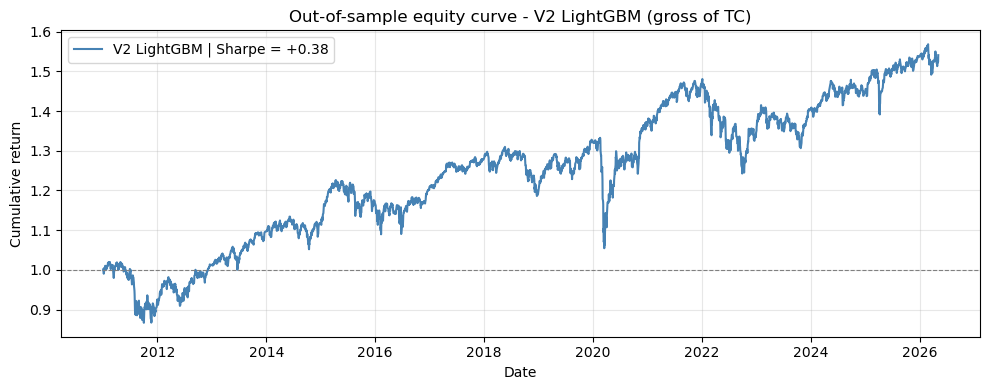

In [7]:
import matplotlib.pyplot as plt

# equal-weighted portfolio return = position x next-day return, averaged across stocks each day
eval_df = positions_filtered.merge(
    feat[["date", "ticker", "next_return"]],
    on=["date", "ticker"],
    how="inner",
)
eval_df["strat_ret"] = eval_df["position"] * eval_df["next_return"]

daily_ret = eval_df.groupby("date")["strat_ret"].mean().sort_index()
cum_ret = (1 + daily_ret).cumprod()

ann_ret = daily_ret.mean() * 252
ann_vol = daily_ret.std() * np.sqrt(252)
sharpe = ann_ret / ann_vol if ann_vol > 0 else float("nan")
max_dd = (cum_ret / cum_ret.cummax() - 1).min()
hit_rate = (eval_df["strat_ret"] > 0).mean()

print("Out-of-sample performance, equal-weighted and gross of TC")
print("Annualised return:", f"{ann_ret:.2%}")
print("Annualised vol   :", f"{ann_vol:.2%}")
print("Sharpe ratio     :", f"{sharpe:+.3f}")
print("Max drawdown     :", f"{max_dd:.2%}")
print("Hit rate         :", f"{hit_rate:.1%}")
print("Trading days     :", f"{daily_ret.shape[0]:,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cum_ret.index, cum_ret.values, color="steelblue", linewidth=1.5,
        label=f"V2 LightGBM | Sharpe = {sharpe:+.2f}")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.set_title("Out-of-sample equity curve - V2 LightGBM (gross of TC)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Sharpe annuel — V1 LSTM vs V2 LightGBM (période commune 2011–2025)

,year,V2 LightGBM,V1 LSTM
0,2011,-0.6110,-0.8280
1,2012,1.1310,1.3190
2,2013,1.3620,1.8800
3,2014,0.3410,-0.0080
4,2015,0.5620,0.7850
5,2016,0.3920,0.2170
6,2017,1.4340,2.8860
7,2018,-1.1010,-0.9130
8,2019,1.7660,1.3780
9,2020,0.2620,-1.5560


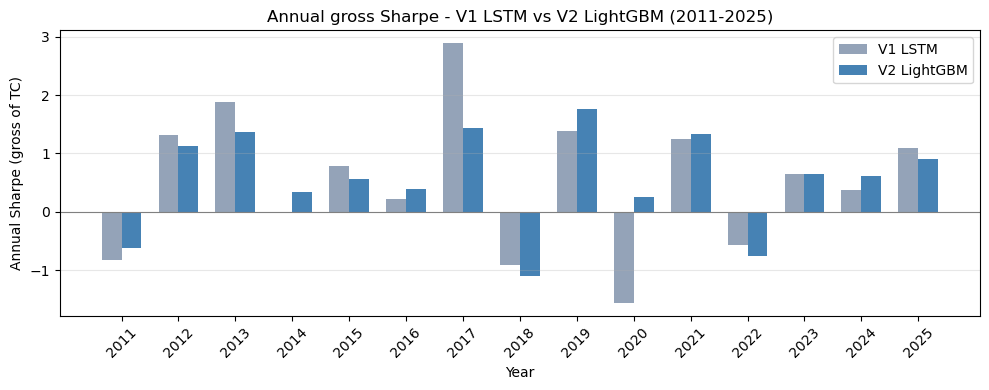

In [8]:
import matplotlib.pyplot as plt
import numpy as np


# per-year Sharpe ratio of a daily-return column, used to compare V1 and V2 year by year
def annual_sharpe_table(data, ret_col, label):
    tmp = data.copy()
    tmp["year"] = pd.to_datetime(tmp["date"]).dt.year

    rows = []
    for year, grp in tmp.groupby("year"):
        daily_ret = grp.groupby("date")[ret_col].mean()
        ann_ret = daily_ret.mean() * 252
        ann_vol = daily_ret.std() * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else float("nan")
        rows.append({"year": year, label: round(sharpe, 3)})
    return pd.DataFrame(rows)


v2_df = annual_sharpe_table(eval_df, "strat_ret", "V2 LightGBM")

# load V1 LSTM's saved test-fold predictions (produced by scripts/03bis_walk_forward.py) for comparison
V1_SUFFIX = "expanding_cpd21_s5_longonly_tc25bps"
models_dir = ROOT / cfg["data"]["processed_mod"]
v1_all = []

for i in range(len(cfg[f"folds_{cfg['fold_type']}"])):
    path = models_dir / f"predictions_fold{i}_{V1_SUFFIX}.csv"
    if path.exists():
        v1_all.append(pd.read_csv(path, parse_dates=["date"]))

if v1_all:
    v1_full = pd.concat(v1_all, ignore_index=True)
    v1_df = annual_sharpe_table(v1_full, "strat_ret", "V1 LSTM")
    cmp = v2_df.merge(v1_df, on="year", how="inner").sort_values("year")
else:
    cmp = v2_df.copy()
    cmp["V1 LSTM"] = float("nan")
    print("V1 predictions not found -- run scripts/03bis_walk_forward.py first.")

cmp = cmp[cmp["year"].between(2011, 2025)].reset_index(drop=True)
display(cmp)

years = cmp["year"].astype(str).tolist()
x = np.arange(len(years))
width = 0.35
has_v1 = cmp["V1 LSTM"].notna().any()

fig, ax = plt.subplots(figsize=(10, 4))
if has_v1:
    ax.bar(x - width / 2, cmp["V1 LSTM"].fillna(0), width, label="V1 LSTM", color="#94a3b8")
    ax.bar(x + width / 2, cmp["V2 LightGBM"], width, label="V2 LightGBM", color="steelblue")
else:
    ax.bar(x, cmp["V2 LightGBM"], width, label="V2 LightGBM", color="steelblue")

ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Sharpe (gross of TC)")
ax.set_title("Annual gross Sharpe - V1 LSTM vs V2 LightGBM (2011-2025)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 7. Interprétabilité — SHAP

Modèle entraîné sur panel complet pour stabiliser les valeurs SHAP.

> 📌 *`macd_32_96` domine → momentum moyen terme (96j). Les 2 features CPD contribuent positivement mais marginalement — leur faible corrélation mutuelle (CUSUM↔BOCPD = 0.11) justifie de les garder tous les deux.*

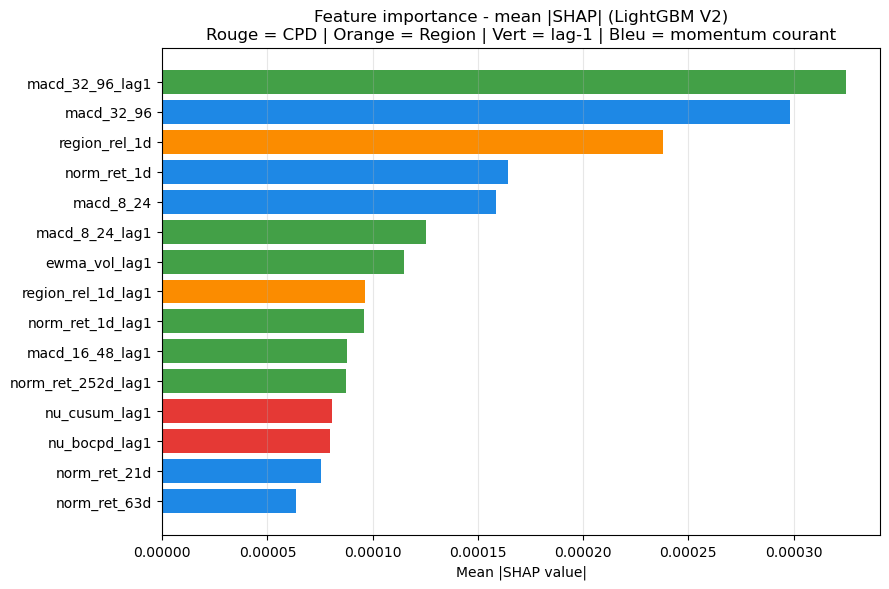

In [9]:
import matplotlib.pyplot as plt

# retrain once on the full panel (more stable SHAP values than a single fold's model)
X_all_df = feat.dropna(subset=feature_cols + [TARGET_COL])
X_all = X_all_df[feature_cols].fillna(0.0).to_numpy(dtype=np.float64)
y_all = X_all_df[TARGET_COL].to_numpy(dtype=np.float64)

n_val = max(1_000, int(len(X_all) * 0.10))
model_shap, _, _ = train_fold_lgb(
    X_all[:-n_val], y_all[:-n_val],
    X_all[-n_val:], y_all[-n_val:],
)

shap_df = compute_shap(model_shap, feat, feature_cols)
top = shap_df.head(15).sort_values("mean_abs_shap", ascending=True)


# color-codes each feature by category for the chart below
def shap_color(feature):
    if "nu_" in feature or "gamma_" in feature:
        return "#E53935"
    if "region_rel" in feature:
        return "#FB8C00"
    if "_lag1" in feature:
        return "#43A047"
    return "#1E88E5"


colors = [shap_color(feature) for feature in top["feature"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["mean_abs_shap"], color=colors)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(
    "Feature importance - mean |SHAP| (LightGBM V2)\n"
    "Rouge = CPD | Orange = Region | Vert = lag-1 | Bleu = momentum courant"
)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 8. Export

→ `positions_v2.parquet` + `fold_metrics_v2.parquet` dans `data/processed/stoxx600/` → NB04.

## 9. Limitations

- **IC ≈ 0.005** : signal fragile — le modèle est correct ~50.25% des jours, légèrement au-dessus du hasard.
- **Ajout CPD = gain marginal sur LightGBM** : le gain reste limité par l'IC, pas par l'architecture.


In [10]:
display(save_nb03_outputs(ROOT, positions_filtered, fold_metrics))

,output,rows,path
0,positions,"2,040,178",data/processed/stoxx600/positions_v2.parquet
1,fold_metrics,16,data/processed/stoxx600/fold_metrics_v2.parquet
